# HF TDOA Analysis - Figure 15

This notebook uses the `hf_tdoa` library to analyze HF TDOA measurements.

In [ ]:
import os
import hf_tdoa as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Load WAV Files & Find Chirps

In [2]:
base_dir   = '../data'
data_set   = 'TX_WA5FRF_EL09nn-RX_AB5YO_EL09so-40m'
sweep_rate = 10  # Hz/ms

# Path to chirp template - used for finding chirp locations via cross-correlation
template   = os.path.join('../templates', 'N6RFM_10Hz_per_ms_template.wav')

data_dir   = os.path.join(base_dir, data_set)
wavlist    = tdoa.obtain_wav_list(data_dir)

In [3]:
# Correlate each WAV with a known template chirp to identify chirp locations in each WAV file.
chirps = tdoa.find_chirps(wavlist, template, sweep_rate=sweep_rate, plot_correlation=False)


Finding Chirps via Cross-Correlation
  Path Info:      PathInfo(TX: WA5FRF (EL09nn), RX: AB5YO (EL09so), Range: 40.6 km, Band: 7 MHz)
  Template:       N6RFM_10Hz_per_ms_template.wav
  Sweep Rate:     10 Hz/ms
  Files to Process: 49
  Chirps per File: Top 10



Finding chirps: 100%|██████████| 49/49 [00:02<00:00, 16.44file/s, Chirps=10, Max Corr=5.40e+02]

✓ Completed chirp detection: 49 files processed, 490 total chirps found



## Find TDOAs

In [4]:
debug_TDOAs = False

# Find TDOAs for each propagation mode using the simplified API
# The mode configurations (filter limits, search limits, model coefficients, and plotting params)
# are now stored in hf_tdoa_lib.MODE_CONFIGS

# Process all three modes
for mode_string in ['3F2-1F2', '2F2-1F2']:
    chirps = tdoa.find_TDOAs(chirps, mode_string=mode_string,
                            plot_fft=debug_TDOAs, only_one=debug_TDOAs)

# Build the TDOA configuration dictionary with model coefficients and plotting parameters
tdoa_dct = tdoa.build_tdoa_config(chirps)

# Print calculated model coefficients for verification
print("Calculated TDOA Model Coefficients:")
print("=" * 60)
for set_name, params in tdoa_dct.items():
    slope, intercept = params['model_coeffs']
    mode_str = params['mode_string']
    print(f"{set_name:12s} ({mode_str:8s}): slope={slope:6.1f}, intercept={intercept:6.1f}")
print("=" * 60)
print()


Processing Mode: 3F2-1F2
  Filter Limits:  10.0 - 50.0 Hz
  Search Window:  -0.10 to 0.10 s offset
  Freq Range:     25.0 - 50.0 Hz
  Set Name:       3F2-1F2
  Sweep Rate:     10 Hz/ms
  Files to Process: 49



Finding TDOAs (3F2-1F2): 100%|██████████| 49/49 [00:11<00:00,  4.45file/s, Mean TDOA=3.76 ms]


✓ Completed processing 3F2-1F2: 49 files processed


Processing Mode: 2F2-1F2
  Filter Limits:  10.0 - 50.0 Hz
  Search Window:  -0.10 to 0.10 s offset
  Freq Range:     11.0 - 20.0 Hz
  Set Name:       2F2-1F2
  Sweep Rate:     10 Hz/ms
  Files to Process: 49



Finding TDOAs (2F2-1F2): 100%|██████████| 49/49 [00:10<00:00,  4.69file/s, Mean TDOA=1.87 ms]


✓ Completed processing 2F2-1F2: 49 files processed

Calculated TDOA Model Coefficients:
3F2-1F2      (3F2-1F2 ): slope=  74.9, intercept=   0.5
2F2-1F2      (2F2-1F2 ): slope= 149.8, intercept=   0.7



## Figure 15 - TDOA Measurements and Layer Heights

This figure combines TDOA measurements (a) and layer heights comparison with ionosonde (b) in a single figure with two subplots.

Figure saved to: fig_15.jpg


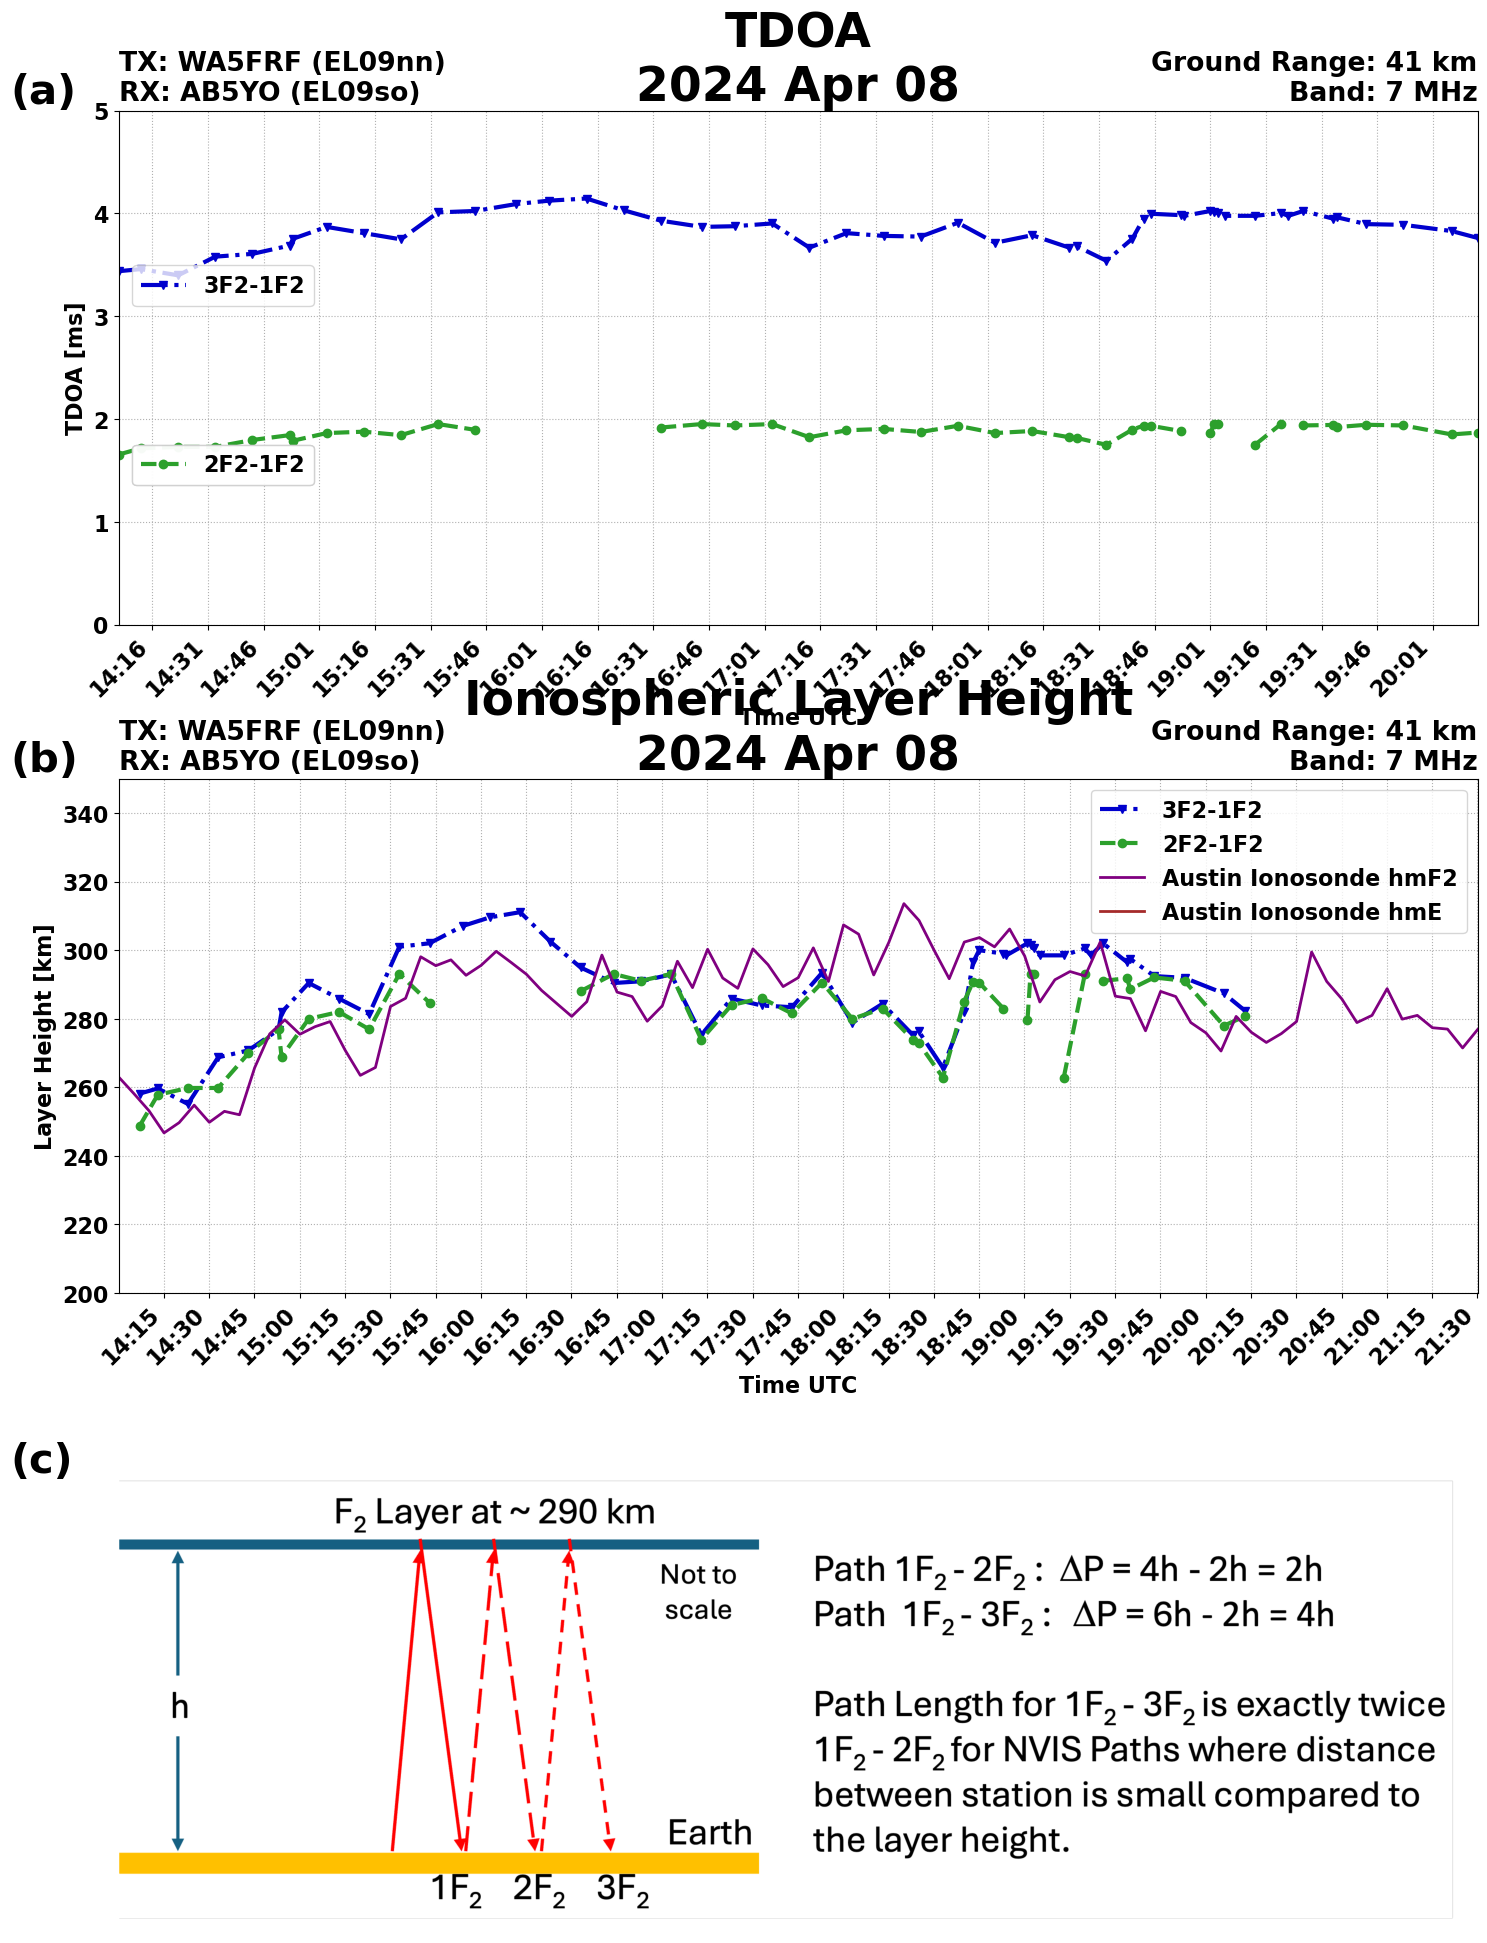

In [5]:
tdoa.plot_tdoa_hmf2_subplot(chirps, tdoa_dct, 
                            ylim_tdoa=(0, 5), 
                            ylim_hmf2=(200, 350),
                            ionosonde_dct=True,
                            image_panel='etalon.png',
                            savefig='fig_15.jpg')

In [6]:
# Access the path_info object stored when chirps were created
path_info = chirps.attrs['path_info']

# Display path information
print(f"Path Information:")
print(f"  {path_info}")
print()

# Get TX and RX coordinates from gridsquares
tx_lat, tx_lon = path_info.get_tx_latlon()
rx_lat, rx_lon = path_info.get_rx_latlon()
print(f"TX Location: {tx_lat:.3f}°N, {tx_lon:.3f}°E ({path_info.tx_grid})")
print(f"RX Location: {rx_lat:.3f}°N, {rx_lon:.3f}°E ({path_info.rx_grid})")
print()

# Calculate the great circle midpoint between TX and RX
mid_lat, mid_lon = path_info.get_midpoint()
print(f"Path Midpoint: {mid_lat:.3f}°N, {mid_lon:.3f}°E")
print()

# Calculate the azimuth from TX to RX
azimuth = path_info.get_path_azimuth()
print(f"Path Azimuth (TX→RX): {azimuth:.1f}°")
print()

Path Information:
  PathInfo(TX: WA5FRF (EL09nn), RX: AB5YO (EL09so), Range: 40.6 km, Band: 7 MHz)

TX Location: 29.563°N, -98.875°E (EL09nn)
RX Location: 29.604°N, -98.458°E (EL09so)

Path Midpoint: 29.583°N, -98.667°E

Path Azimuth (TX→RX): 83.3°

